In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Pre-processing

In [ ]:
import numpy as np
import pandas as pd

from IPython.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Configure Jupyter Notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

reload(plt)
%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

# configure plotly graph objects
pio.renderers.default = 'iframe'
# pio.renderers.default = 'vscode'

pio.templates["ck_template"] = go.layout.Template(
    layout_colorway = px.colors.sequential.Viridis,
#     layout_hovermode = 'closest',
#     layout_hoverdistance = -1,
    layout_autosize=False,
    layout_width=800,
    layout_height=600,
    layout_font = dict(family="Calibri Light"),
    layout_title_font = dict(family="Calibri"),
    layout_hoverlabel_font = dict(family="Calibri Light"),
#     plot_bgcolor="white",
)

# pio.templates.default = 'seaborn+ck_template+gridon'
pio.templates.default = 'ck_template+gridon'
# pio.templates.default = 'seaborn+gridon'
# pio.templates

In [ ]:
index_names = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
col_names = index_names + setting_names + sensor_names

In [ ]:
df_train = pd.read_csv('drive/MyDrive/archive/CMaps/train_FD003.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test = pd.read_csv('drive/MyDrive/archive/CMaps/test_FD003.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test_RUL = pd.read_csv('drive/MyDrive/archive/CMaps/RUL_FD003.txt',sep=r'\s+',header=None,index_col=False,names=['RUL'])

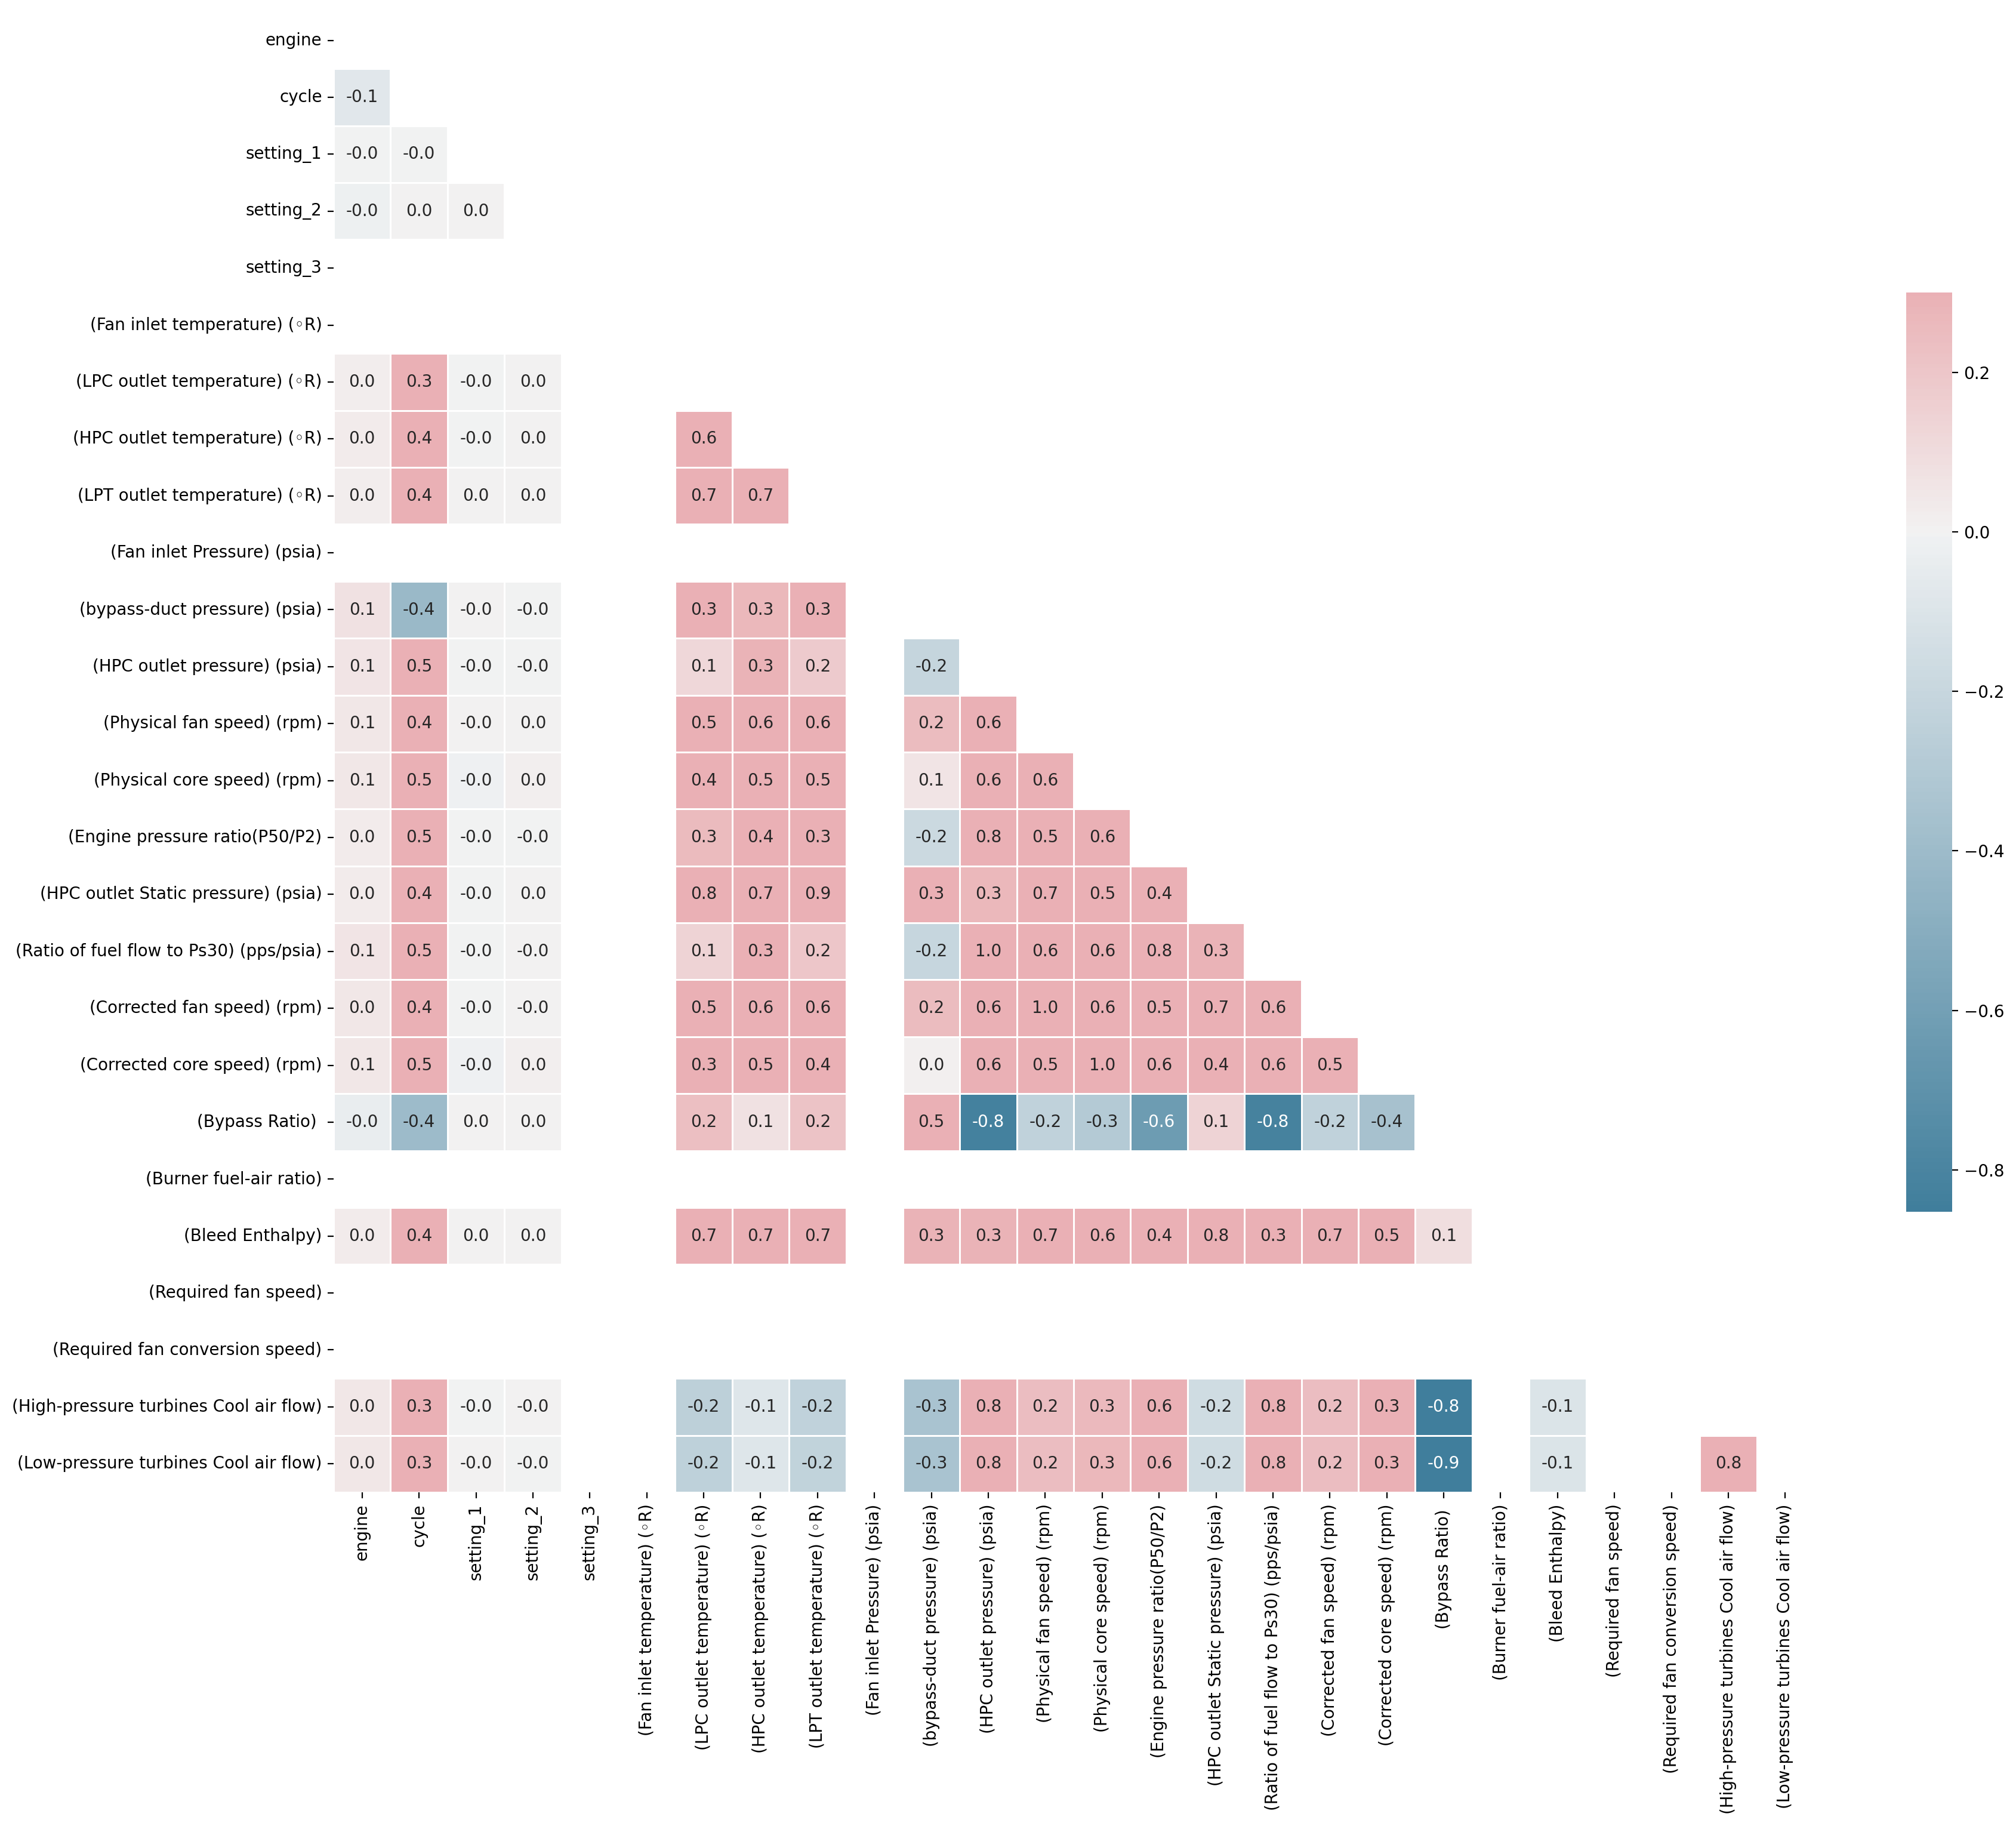

In [ ]:

corr = df_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(230, 10, as_cmap=True)

# Draw the heatmap with annotation
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=.3,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5},
    annot=True,           # <- Add this line
    fmt=".1f"             # <- Format the numbers to 2 decimal places
)

plt.show()


In [ ]:
sens_const_values = []
for feature in list(setting_names + sensor_names):
    try:
        if df_train[feature].min()==df_train[feature].max():
            sens_const_values.append(feature)
    except:
        pass

print(sens_const_values)
df_train.drop(sens_const_values,axis=1,inplace=True)
df_test.drop(sens_const_values,axis=1,inplace=True)

['setting_3', '(Fan inlet temperature) (◦R)', '(Fan inlet Pressure) (psia)', '(Burner fuel-air ratio)', '(Required fan speed)', '(Required fan conversion speed)']


In [ ]:
cor_matrix = df_train.corr().abs()
upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),k=1).astype(np.bool))
corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(corr_features)
df_train.drop(corr_features,axis=1,inplace=True)
df_test.drop(corr_features,axis=1,inplace=True)

['(Ratio of fuel flow to Ps30) (pps/psia)', '(Corrected fan speed) (rpm)', '(Corrected core speed) (rpm)']


In [ ]:
features = list(df_train.columns)

In [ ]:
# check for missing data
for feature in features:
    print(feature + " - " + str(len(df_train[df_train[feature].isna()])))

engine - 0
cycle - 0
setting_1 - 0
setting_2 - 0
(LPC outlet temperature) (◦R) - 0
(HPC outlet temperature) (◦R) - 0
(LPT outlet temperature) (◦R) - 0
(bypass-duct pressure) (psia) - 0
(HPC outlet pressure) (psia) - 0
(Physical fan speed) (rpm) - 0
(Physical core speed) (rpm) - 0
(Engine pressure ratio(P50/P2) - 0
(HPC outlet Static pressure) (psia) - 0
(Bypass Ratio)  - 0
(Bleed Enthalpy) - 0
(High-pressure turbines Cool air flow) - 0
(Low-pressure turbines Cool air flow) - 0


In [ ]:
# define the maximum life of each engine, as this could be used to obtain the RUL at each point in time of the engine's life
df_train_RUL = df_train.groupby(['engine']).agg({'cycle':'max'})
df_train_RUL.rename(columns={'cycle':'life'},inplace=True)
df_train_RUL.head()

,life
engine,
1,259
2,253
3,222
4,272
5,213


In [ ]:
df_train=df_train.merge(df_train_RUL,how='left',on=['engine'])

In [ ]:
df_train['RUL']=df_train['life']-df_train['cycle']
df_train.drop(['life'],axis=1,inplace=True)

# the RUL prediction is only useful nearer to the end of the engine's life, therefore we put an upper limit on the RUL
# this is a bit sneaky, since it supposes that the test set has RULs of less than this value, the closer you are
# to the true value, the more accurate the model will be
df_train['RUL'][df_train['RUL']>125]=125
df_train.head()

,engine,cycle,setting_1,setting_2,(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(Engine pressure ratio(P50/P2),(HPC outlet Static pressure) (psia),(Bypass Ratio),(Bleed Enthalpy),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow),RUL
0,1,1,-0.0005,0.0004,642.36,1583.23,1396.84,21.61,553.97,2387.96,9062.17,1.3,47.30,8.4246,391,39.11,23.3537,125
1,1,2,0.0008,-0.0003,642.50,1584.69,1396.89,21.61,554.55,2388.00,9061.78,1.3,47.23,8.4403,392,38.99,23.4491,125
2,1,3,-0.0014,-0.0002,642.18,1582.35,1405.61,21.61,554.43,2388.03,9070.23,1.3,47.22,8.3901,391,38.85,23.3669,125
3,1,4,-0.0020,0.0001,642.92,1585.61,1392.27,21.61,555.21,2388.00,9064.57,1.3,47.24,8.3878,392,38.96,23.2951,125
4,1,5,0.0016,0.0000,641.68,1588.63,1397.65,21.61,554.74,2388.04,9076.14,1.3,47.15,8.3869,392,39.14,23.4583,125


In [ ]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
CONFIG = {
    'WINDOW_SIZE': 30,
    'STRIDE': 1,
    'LSTM_UNITS': [128, 64],
    'DENSE_UNITS': 50,
    'DROPOUT_RATE': 0.3,
    'L2_REG': 0.001,
    'BATCH_SIZE': 64,
    'EPOCHS': 150,
    'LEARNING_RATE': 0.001,
    'PATIENCE': 25,
    'N_SPLITS': 5,
}

print("\nConfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")


Configuration:
  WINDOW_SIZE: 30
  STRIDE: 1
  LSTM_UNITS: [128, 64]
  DENSE_UNITS: 50
  DROPOUT_RATE: 0.3
  L2_REG: 0.001
  BATCH_SIZE: 64
  EPOCHS: 150
  LEARNING_RATE: 0.001
  PATIENCE: 25
  N_SPLITS: 5


In [ ]:
feature_cols = [col for col in df_train.columns
                if col not in ['engine', 'cycle', 'RUL']]

print(f"✓ Training data: {df_train.shape}")
print(f"✓ Test data: {df_test.shape}")
print(f"✓ Features: {len(feature_cols)}")

✓ Training data: (24720, 18)
✓ Test data: (16596, 17)
✓ Features: 15


In [ ]:
scaler = StandardScaler()

df_train_norm = df_train.copy()
df_test_norm = df_test.copy()

# Fit on TRAINING data only
df_train_norm[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test_norm[feature_cols] = scaler.transform(df_test[feature_cols])

print(f"✓ Normalized {len(feature_cols)} features")
print(f"  Method: StandardScaler")

✓ Normalized 15 features
  Method: StandardScaler


In [ ]:
def create_sequences(df, window_size, stride, feature_cols, is_train=True):
    """Create sequences using sliding window"""
    X_list = []
    y_list = []
    engine_ids_list = []

    for engine_id, engine_data in df.groupby('engine'):
        engine_data = engine_data.sort_values('cycle').reset_index(drop=True)
        features = engine_data[feature_cols].values

        if len(engine_data) < window_size:
            continue

        if is_train:
            rul = engine_data['RUL'].values
            for i in range(0, len(engine_data) - window_size + 1, stride):
                X_list.append(features[i:i + window_size])
                y_list.append(rul[i + window_size - 1])
                engine_ids_list.append(engine_id)
        else:
            for i in range(0, len(engine_data) - window_size + 1, stride):
                X_list.append(features[i:i + window_size])
                engine_ids_list.append(engine_id)

    X = np.array(X_list)
    engine_ids = np.array(engine_ids_list)

    if is_train:
        y = np.array(y_list)
        return X, y, engine_ids
    else:
        return X, engine_ids

# Create sequences
X_train, y_train, train_engine_ids = create_sequences(
    df_train_norm, CONFIG['WINDOW_SIZE'], CONFIG['STRIDE'],
    feature_cols, is_train=True
)

X_test, test_engine_ids = create_sequences(
    df_test_norm, CONFIG['WINDOW_SIZE'], CONFIG['STRIDE'],
    feature_cols, is_train=False
)

print(f"✓ Training sequences: {X_train.shape}")
print(f"  - Samples: {X_train.shape[0]}")
print(f"  - Timesteps: {X_train.shape[1]}")
print(f"  - Features: {X_train.shape[2]}")
print(f"✓ Test sequences: {X_test.shape}")

✓ Training sequences: (21820, 30, 15)
  - Samples: 21820
  - Timesteps: 30
  - Features: 15
✓ Test sequences: (13696, 30, 15)


In [ ]:
class GatingLayer(layers.Layer):
    """
    Custom gating layer to learn branch importance dynamically
    This is the NOVEL component!
    """
    def __init__(self, num_branches, **kwargs):
        super(GatingLayer, self).__init__(**kwargs)
        self.num_branches = num_branches

    def build(self, input_shape):
        # Gating weights (one per branch)
        # input_shape will be a list of shapes, e.g., [(None, timesteps, features), ...]
        # We need the last dimension (features) from one of these shapes
        self.gate_weights = self.add_weight(
            shape=(input_shape[0][-1], self.num_branches),
            initializer='glorot_uniform',
            trainable=True,
            name='gate_weights'
        )
        self.gate_bias = self.add_weight(
            shape=(self.num_branches,),
            initializer='zeros',
            trainable=True,
            name='gate_bias'
        )

    def call(self, inputs):
        # inputs: list of [branch_1, branch_2, branch_3]
        # Each branch shape: (batch, timesteps, features)

        # Compute gating scores from input statistics
        input_stats = tf.reduce_mean(inputs[0], axis=1)  # (batch, features)
        gate_scores = tf.nn.softmax(
            tf.matmul(input_stats, self.gate_weights) + self.gate_bias,
            axis=-1
        )  # (batch, num_branches)

        # Apply gates to each branch
        gate_scores = tf.expand_dims(gate_scores, 1)  # (batch, 1, num_branches)
        gate_scores = tf.expand_dims(gate_scores, -1)  # (batch, 1, num_branches, 1)

        # Stack branches
        stacked = tf.stack(inputs, axis=2)  # (batch, timesteps, num_branches, features)

        # Apply gating
        gated = stacked * gate_scores  # Broadcasting

        # Sum across branches
        fused = tf.reduce_sum(gated, axis=2)  # (batch, timesteps, features)

        return fused

    def get_config(self):
        config = super().get_config()
        config.update({"num_branches": self.num_branches})
        return config

print("✓ Gating layer defined")

✓ Gating layer defined


In [ ]:
def build_gated_ensemble_bilstm(input_shape, config):
    """
    NOVEL Gated Ensemble BiLSTM Architecture

    Layer 1: Parallel branches (LSTM, GRU, CNN)
    Layer 2: Learned gating mechanism
    Layer 3-4: BiLSTM layers
    Layer 5: Dense output
    """

    inputs = layers.Input(shape=input_shape, name='input')

    # ========================================================================
    # LAYER 1: PARALLEL BRANCHES (ENSEMBLE)
    # ========================================================================

    # Branch 1: LSTM (traditional temporal modeling)
    branch_lstm = layers.LSTM(
        64,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(config['L2_REG']),
        recurrent_regularizer=regularizers.l2(config['L2_REG']),
        name='lstm_branch'
    )(inputs)
    branch_lstm = layers.LayerNormalization(name='ln_lstm')(branch_lstm)
    branch_lstm = layers.Dropout(config['DROPOUT_RATE'], name='dropout_lstm')(branch_lstm)

    # Branch 2: GRU (simpler gating, different dynamics)
    branch_gru = layers.GRU(
        64,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(config['L2_REG']),
        recurrent_regularizer=regularizers.l2(config['L2_REG']),
        name='gru_branch'
    )(inputs)
    branch_gru = layers.LayerNormalization(name='ln_gru')(branch_gru)
    branch_gru = layers.Dropout(config['DROPOUT_RATE'], name='dropout_gru')(branch_gru)

    # Branch 3: 1D CNN (local pattern detection)
    branch_cnn = layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding='same',
        activation='relu',
        kernel_regularizer=regularizers.l2(config['L2_REG']),
        name='cnn_branch'
    )(inputs)
    branch_cnn = layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding='same',
        activation='relu',
        kernel_regularizer=regularizers.l2(config['L2_REG']),
        name='cnn_branch_2'
    )(branch_cnn)
    branch_cnn = layers.LayerNormalization(name='ln_cnn')(branch_cnn)
    branch_cnn = layers.Dropout(config['DROPOUT_RATE'], name='dropout_cnn')(branch_cnn)

    # ========================================================================
    # LAYER 2: GATED FUSION (NOVEL!)
    # ========================================================================

    # Learnable gating mechanism
    gating = GatingLayer(num_branches=3, name='gating_layer')
    fused_features = gating([branch_lstm, branch_gru, branch_cnn])

    # ========================================================================
    # LAYER 3: BiLSTM (Process Fused Features)
    # ========================================================================

    x = layers.Bidirectional(
        layers.LSTM(
            config['LSTM_UNITS'][0],
            return_sequences=True,
            kernel_regularizer=regularizers.l2(config['L2_REG']),
            recurrent_regularizer=regularizers.l2(config['L2_REG']),
            name='bilstm_1'
        ),
        name='bidirectional_1'
    )(fused_features)
    x = layers.LayerNormalization(name='ln_1')(x)
    x = layers.Dropout(config['DROPOUT_RATE'], name='dropout_1')(x)

    # ========================================================================
    # LAYER 4: Second BiLSTM
    # ========================================================================

    x = layers.Bidirectional(
        layers.LSTM(
            config['LSTM_UNITS'][1],
            return_sequences=False,
            kernel_regularizer=regularizers.l2(config['L2_REG']),
            recurrent_regularizer=regularizers.l2(config['L2_REG']),
            name='bilstm_2'
        ),
        name='bidirectional_2'
    )(x)
    x = layers.LayerNormalization(name='ln_2')(x)
    x = layers.Dropout(config['DROPOUT_RATE'], name='dropout_2')(x)

    # ========================================================================
    # LAYER 5: Dense Layers
    # ========================================================================

    x = layers.Dense(
        config['DENSE_UNITS'],
        activation='relu',
        kernel_regularizer=regularizers.l2(config['L2_REG']),
        name='dense_1'
    )(x)
    x = layers.Dropout(config['DROPOUT_RATE'], name='dropout_3')(x)

    # Output
    outputs = layers.Dense(1, activation='linear', name='rul_output')(x)

    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name='Gated_Ensemble_BiLSTM')

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=config['LEARNING_RATE']),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae', 'mse']
    )

    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_gated_ensemble_bilstm(input_shape, CONFIG)

print("\nModel Architecture:")
model.summary()

print("\n✓ NOVEL Architecture Components:")
print("  1. Parallel Branches: LSTM + GRU + CNN")
print("  2. Gating Layer: Learns branch importance dynamically")
print("  3. BiLSTM Integration: Processes fused features")
print("  4. Total Parameters: ~", model.count_params())


Model Architecture:


Model: "Gated_Ensemble_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 15)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch (Conv1D) │ (None, 30, 64)    │      4,864 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_branch (LSTM)  │ (None, 30, 64)    │     20,480 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_branch (GRU)    │ (None, 30, 64)    │     15,552 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch_2        │ (None, 30, 64)    │     12,352 │ cnn_branch[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_lstm             │ (None, 30, 64)    │        128 │ lstm_branch[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_gru              │ (None, 30, 64)    │        128 │ gru_branch[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_cnn              │ (None, 30, 64)    │        128 │ cnn_branch_2[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm        │ (None, 30, 64)    │          0 │ ln_lstm[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_gru         │ (None, 30, 64)    │          0 │ ln_gru[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_cnn         │ (None, 30, 64)    │          0 │ ln_cnn[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gating_layer        │ (None, 30, 64)    │        195 │ dropout_lstm[0][… │
│ (GatingLayer)       │                   │            │ dropout_gru[0][0… │
│                     │                   │            │ dropout_cnn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 30, 256)   │    197,632 │ gating_layer[0][… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1                │ (None, 30, 256)   │        512 │ bidirectional_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 256)   │          0 │ ln_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128)       │    164,352 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2                │ (None, 128)       │        256 │ bidirectional_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ ln_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 423,080 (1.61 MB)

 Trainable params: 423,080 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


✓ NOVEL Architecture Components:
  1. Parallel Branches: LSTM + GRU + CNN
  2. Gating Layer: Learns branch importance dynamically
  3. BiLSTM Integration: Processes fused features
  4. Total Parameters: ~ 423080


In [ ]:
gkf = GroupKFold(n_splits=CONFIG['N_SPLITS'])

fold_models = []
fold_histories = []
fold_val_scores = []

print(f"Training with {CONFIG['N_SPLITS']}-Fold Cross-Validation\n")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, train_engine_ids), 1):
    print(f"\n{'='*70}")
    print(f"FOLD {fold}/{CONFIG['N_SPLITS']}")
    print(f"{'='*70}")

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    print(f"Train: {len(X_tr)} samples, Val: {len(X_val)} samples")

    # Build fresh model
    model = build_gated_ensemble_bilstm(input_shape, CONFIG)

    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['PATIENCE'],
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=0
    )

    # Train
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=CONFIG['EPOCHS'],
        batch_size=CONFIG['BATCH_SIZE'],
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Evaluate
    val_loss, val_mae, val_mse = model.evaluate(X_val, y_val, verbose=0)
    val_rmse = np.sqrt(val_mse)
    y_val_pred = model.predict(X_val, verbose=0).flatten()
    val_r2 = r2_score(y_val, y_val_pred)

    print(f"\n✓ Fold {fold} Results:")
    print(f"  Val MAE:  {val_mae:.4f}")
    print(f"  Val RMSE: {val_rmse:.4f}")
    print(f"  Val R²:   {val_r2:.4f}")
    print(f"  Epochs:   {len(history.history['loss'])}")

    fold_models.append(model)
    fold_histories.append(history)
    fold_val_scores.append({
        'mae': val_mae,
        'rmse': val_rmse,
        'r2': val_r2
    })

Training with 5-Fold Cross-Validation


FOLD 1/5
Train: 17458 samples, Val: 4362 samples
Epoch 1/150
273/273 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 50.3908 - mae: 49.4933 - mse: 3927.1646 - val_loss: 15.2034 - val_mae: 14.4072 - val_mse: 397.6722 - learning_rate: 0.0010
Epoch 2/150
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 17.8507 - mae: 17.0685 - mse: 488.7146 - val_loss: 14.4241 - val_mae: 13.6943 - val_mse: 345.7303 - learning_rate: 0.0010
Epoch 3/150
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 16.6241 - mae: 15.9037 - mse: 432.7045 - val_loss: 12.9815 - val_mae: 12.3019 - val_mse: 334.1152 - learning_rate: 0.0010
Epoch 4/150
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 16.1160 - mae: 15.4482 - mse: 409.3714 - val_loss: 12.5125 - val_mae: 11.8821 - val_mse: 313.8752 - learning_rate: 0.0010
Epoch 5/150
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 15.4520 - mae: 14.8271 - mse: 374.8835 - val_loss: 11.8229 - val_mae: 11.2264 - val_mse: 275.5575 - learning_r

In [ ]:
# Cross-validation summary
cv_mae = [s['mae'] for s in fold_val_scores]
cv_rmse = [s['rmse'] for s in fold_val_scores]
cv_r2 = [s['r2'] for s in fold_val_scores]

print(f"Cross-Validation Results:")
print(f"  MAE:  {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"  RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}")
print(f"  R²:   {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")

# Select best model
best_fold_idx = np.argmin(cv_mae)
best_model = fold_models[best_fold_idx]
print(f"\n✓ Best model: Fold {best_fold_idx + 1}")

# Predict on test set
y_test_pred_all = best_model.predict(X_test, verbose=0).flatten()
y_test_pred_all = np.clip(y_test_pred_all, 0, None)

# Aggregate per engine (use LAST window prediction)
unique_test_engines = sorted(set(test_engine_ids))
y_test_final = []
y_pred_final = []

for engine_id in unique_test_engines:
    engine_mask = test_engine_ids == engine_id
    engine_predictions = y_test_pred_all[engine_mask]

    # Use last prediction
    y_pred_final.append(engine_predictions[-1])

    # Get true RUL
    true_rul = df_test_RUL.iloc[int(engine_id) - 1]['RUL']
    y_test_final.append(true_rul)

y_test_final = np.array(y_test_final)
y_pred_final = np.array(y_pred_final)

# Calculate metrics
test_mae = mean_absolute_error(y_test_final, y_pred_final)
test_rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
test_r2 = r2_score(y_test_final, y_pred_final)
test_mape = np.mean(np.abs((y_test_final - y_pred_final) / (y_test_final + 1e-8))) * 100

print(f"\n✓ Test Set Results ({len(y_test_final)} engines):")
print(f"  MAE:  {test_mae:.4f} cycles")
print(f"  RMSE: {test_rmse:.4f} cycles")
print(f"  R²:   {test_r2:.4f}")
print(f"  MAPE: {test_mape:.2f}%")

print(f"\n  Diagnostics:")
print(f"    Mean pred: {y_pred_final.mean():.2f}, Mean actual: {y_test_final.mean():.2f}")
print(f"    Std pred:  {y_pred_final.std():.2f}, Std actual:  {y_test_final.std():.2f}")


Cross-Validation Results:
  MAE:  9.1701 ± 0.7570
  RMSE: 14.8413 ± 1.1220
  R²:   0.8710 ± 0.0190

✓ Best model: Fold 3

✓ Test Set Results (100 engines):
  MAE:  13.3647 cycles
  RMSE: 18.6268 cycles
  R²:   0.7975
  MAPE: 21.63%

  Diagnostics:
    Mean pred: 78.26, Mean actual: 75.32
    Std pred:  40.16, Std actual:  41.40


✓ Saved: gated_ensemble_bilstm_results.png


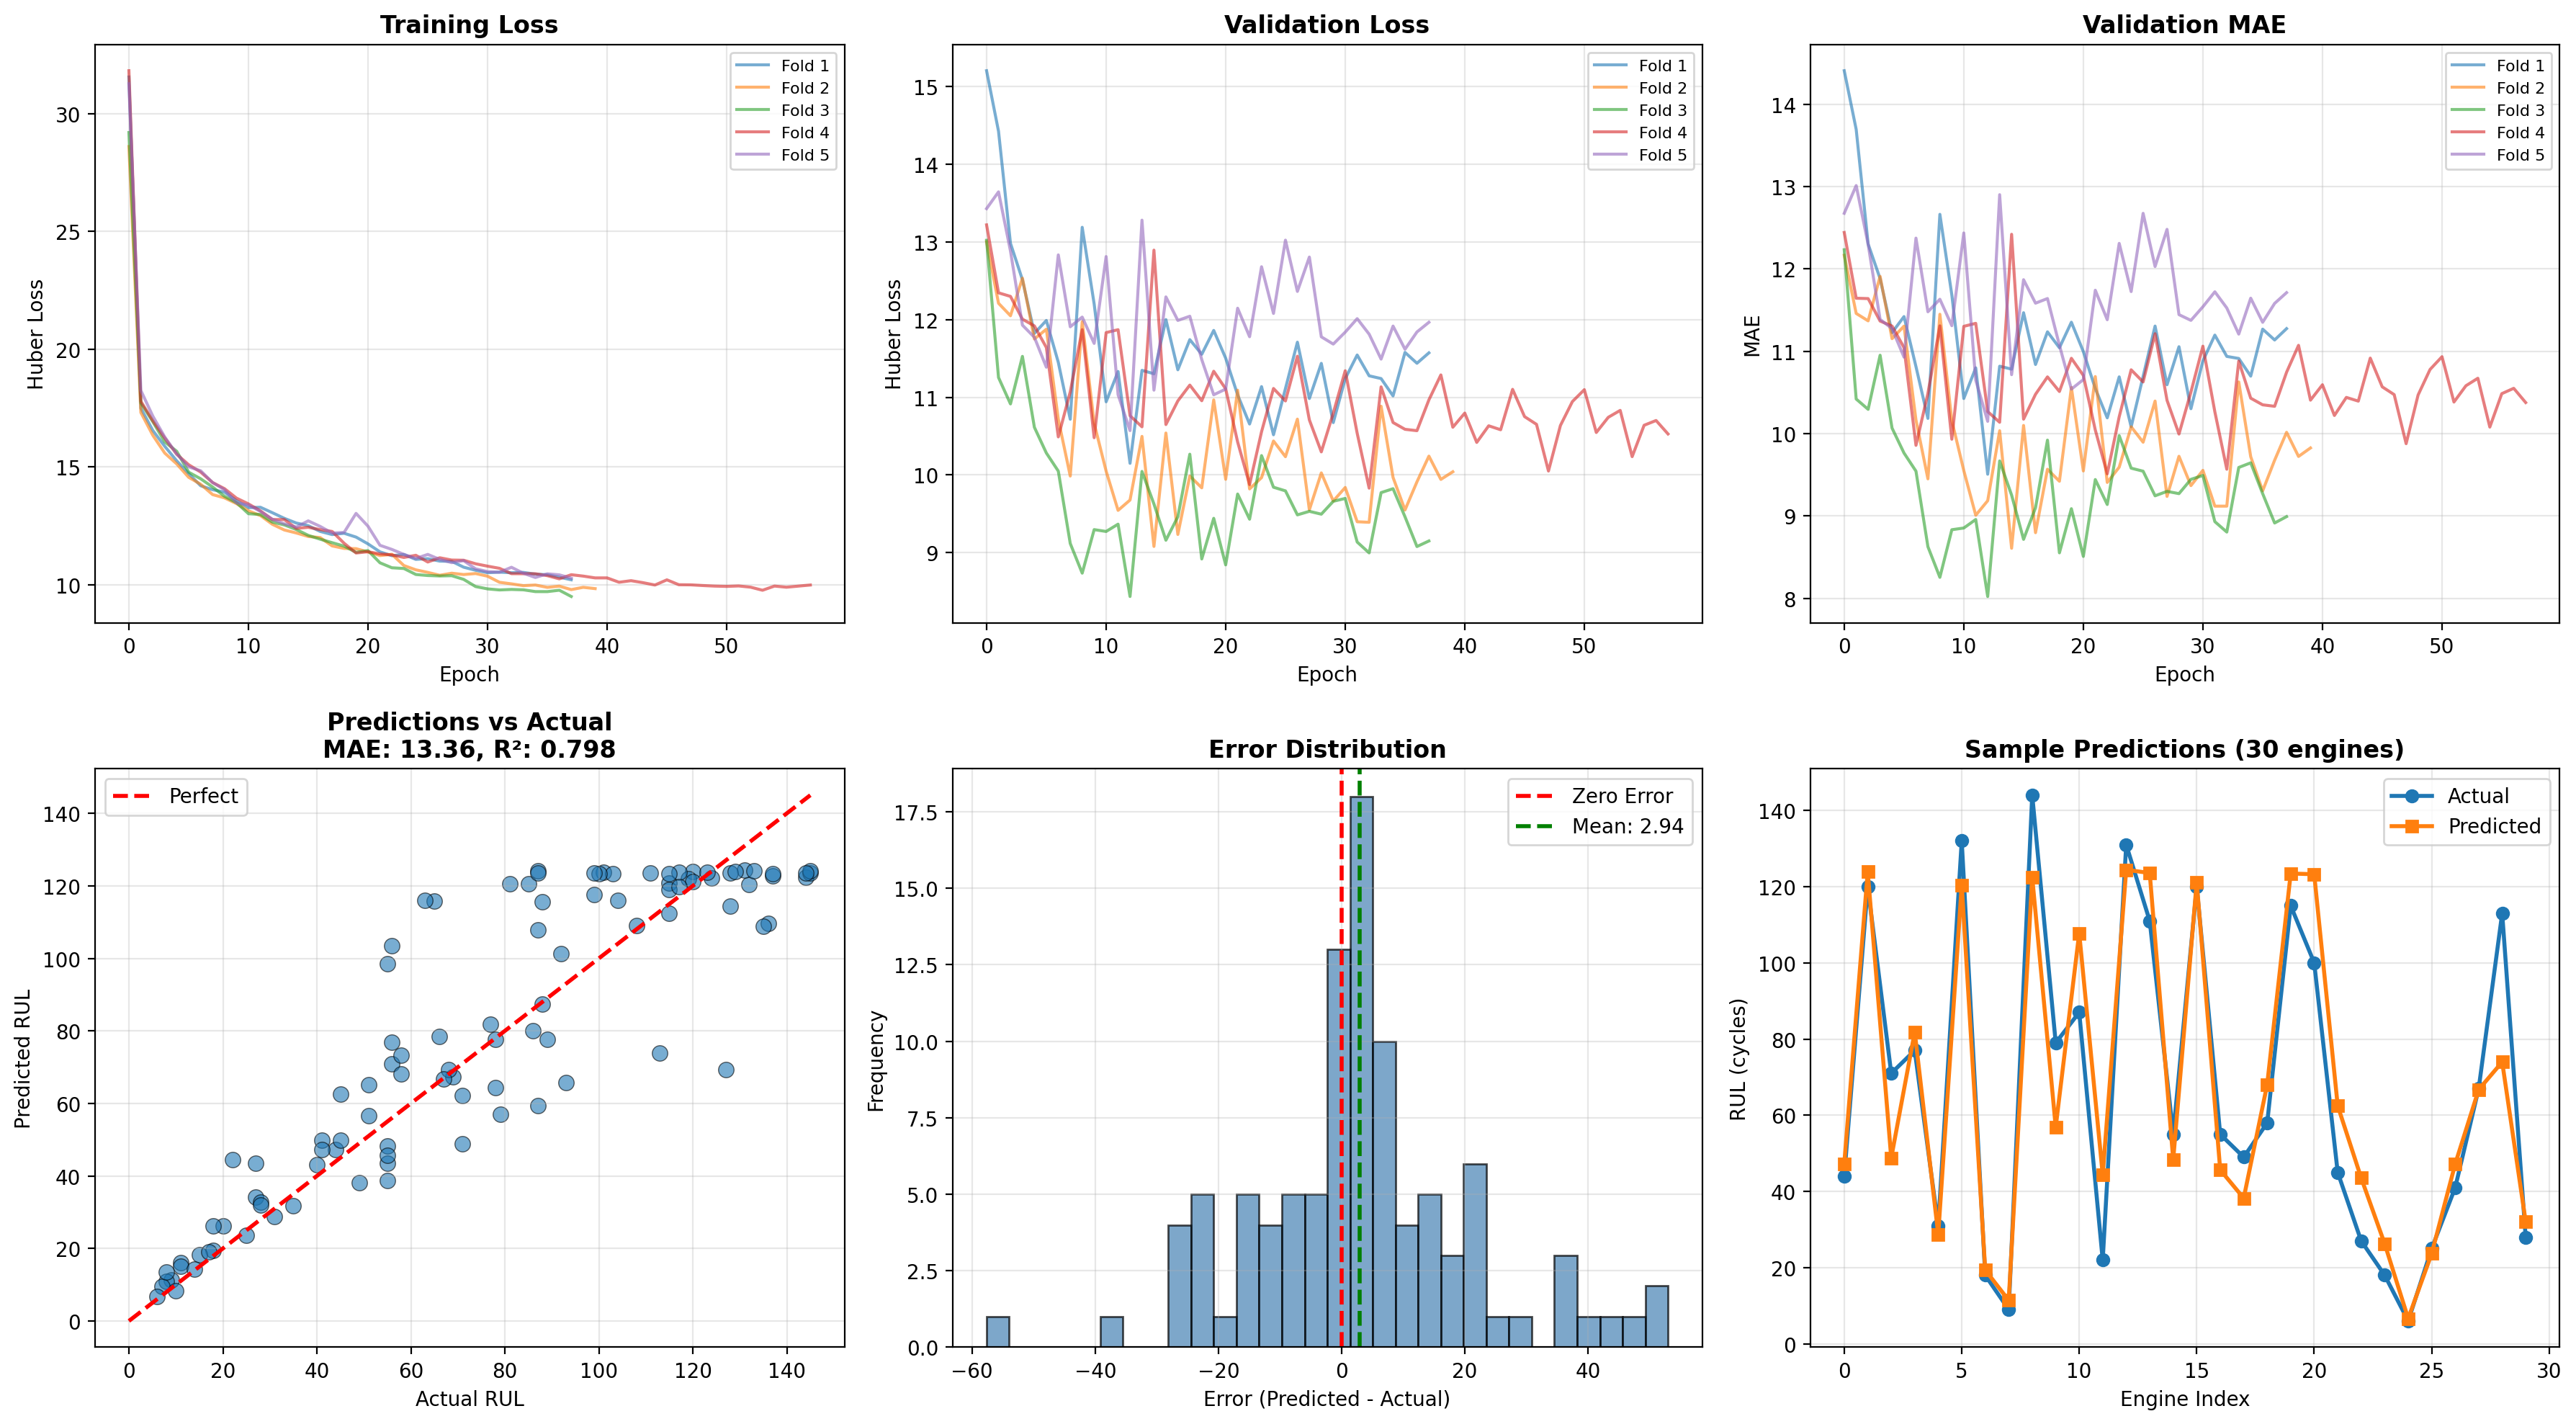

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Training history
ax = axes[0, 0]
for i, history in enumerate(fold_histories, 1):
    ax.plot(history.history['loss'], label=f'Fold {i}', alpha=0.6)
ax.set_title('Training Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Validation history
ax = axes[0, 1]
for i, history in enumerate(fold_histories, 1):
    ax.plot(history.history['val_loss'], label=f'Fold {i}', alpha=0.6)
ax.set_title('Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. MAE history
ax = axes[0, 2]
for i, history in enumerate(fold_histories, 1):
    ax.plot(history.history['val_mae'], label=f'Fold {i}', alpha=0.6)
ax.set_title('Validation MAE', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4. Predictions vs Actual
ax = axes[1, 0]
ax.scatter(y_test_final, y_pred_final, alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
max_val = max(y_test_final.max(), y_pred_final.max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title(f'Predictions vs Actual\nMAE: {test_mae:.2f}, R²: {test_r2:.3f}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Error distribution
ax = axes[1, 1]
errors = y_pred_final - y_test_final
ax.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
ax.axvline(x=np.mean(errors), color='green', linestyle='--', lw=2, label=f'Mean: {np.mean(errors):.2f}')
ax.set_xlabel('Error (Predicted - Actual)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Sample predictions
ax = axes[1, 2]
n_samples = min(30, len(y_test_final))
sample_indices = np.linspace(0, len(y_test_final)-1, n_samples, dtype=int)
x_pos = np.arange(n_samples)
ax.plot(x_pos, y_test_final[sample_indices], 'o-', label='Actual', markersize=6, linewidth=2)
ax.plot(x_pos, y_pred_final[sample_indices], 's-', label='Predicted', markersize=6, linewidth=2)
ax.set_xlabel('Engine Index')
ax.set_ylabel('RUL (cycles)')
ax.set_title(f'Sample Predictions ({n_samples} engines)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gated_ensemble_bilstm_results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: gated_ensemble_bilstm_results.png")
plt.show()


In [ ]:
print(f"\n✓ Training Complete!")
print(f"\nArchitecture: Gated Ensemble BiLSTM (NOVEL)")
print(f"  - 3 parallel branches (LSTM, GRU, CNN)")
print(f"  - Learned gating mechanism")
print(f"  - 2 BiLSTM integration layers")

print(f"\nPerformance:")
print(f"  Cross-Validation MAE:  {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"  Cross-Validation R²:   {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"  Test MAE:  {test_mae:.4f}")
print(f"  Test RMSE: {test_rmse:.4f}")
print(f"  Test R²:   {test_r2:.4f}")

# Performance assessment
if test_r2 >= 0.85:
    print("\n  🏆🏆 OUTSTANDING performance (R² ≥ 0.85)")
elif test_r2 >= 0.80:
    print("\n  🏆 EXCELLENT performance (0.80 ≤ R² < 0.85)")
elif test_r2 >= 0.70:
    print("\n  ✅ GOOD performance (0.70 ≤ R² < 0.80)")
else:
    print("\n  ⚠️  MODERATE performance (R² < 0.70)")


✓ Training Complete!

Architecture: Gated Ensemble BiLSTM (NOVEL)
  - 3 parallel branches (LSTM, GRU, CNN)
  - Learned gating mechanism
  - 2 BiLSTM integration layers

Performance:
  Cross-Validation MAE:  9.1701 ± 0.7570
  Cross-Validation R²:   0.8710 ± 0.0190
  Test MAE:  13.3647
  Test RMSE: 18.6268
  Test R²:   0.7975

  ✅ GOOD performance (0.70 ≤ R² < 0.80)
